In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
circuits_df = pd.read_csv('./data/cleaned_circuits.csv')
constructor_results_df = pd.read_csv('./data/cleaned_constructor_results.csv')
constructor_standings_df = pd.read_csv('./data/cleaned_constructor_standings.csv')
constructor_df = pd.read_csv('./data/cleaned_constructors.csv')
drivers_df = pd.read_csv('./data/cleaned_drivers.csv')
driver_standings_df = pd.read_csv('./data/cleaned_driver_standings.csv')
lap_times_df = pd.read_csv('./data/cleaned_lap_times.csv')
pit_stops_df = pd.read_csv('./data/cleaned_pit_stops.csv')
qualifying_df = pd.read_csv('./data/cleaned_qualifying.csv')
races_df = pd.read_csv('./data/cleaned_races.csv')
results_df = pd.read_csv('./data/cleaned_results.csv')
seasons_df = pd.read_csv('./data/cleaned_seasons.csv')
sprint_results_df = pd.read_csv('./data/cleaned_sprint_results.csv')
status_df = pd.read_csv('./data/cleaned_status.csv')


## DF Column Info

#### circuits_df:
'circuitId', 'circuit_name', 'circuit_location', 'circuit_country', 'circuit_nationality'

#### constructor_results_df:
'constructorResultsId', 'raceId', 'constructorId', 'points'

#### constructor_standings_df:
'constructorStandingsId', 'raceId', 'constructorId', 'points', 'position', 'wins'

#### constructor_df:
'constructorId', 'constructor_name', 'constructor_nationality', 'constructor_home'

#### drivers_df:
'driverId', 'driver_code', 'driver_forename', 'driver_surname', 'driver_dob', 'driver_nationality', 'driver_home'

#### driver_standings_df:
'driverStandingsId', 'raceId', 'driverId', 'points', 'position', 'wins'

#### lap_times_df:
'raceId', 'driverId', 'lap', 'position', 'lap_time'

#### pit_stops_df:
'raceId', 'driverId', 'stop', 'lap', 'milliseconds'

#### qualifying_df:
'qualifyId', 'raceId', 'driverId', 'constructorId', 'number',
       'position', 'q1', 'q2', 'q3'

#### races_df:
'raceId', 'year', 'round', 'circuitId'

#### results_df:
'resultId', 'raceId', 'driverId', 'constructorId', 'grid_position',
       'position', 'points', 'laps', 'fastestLap', 'fastestLapRank',
       'fastestLapTime', 'fastestLapSpeed', 'statusId'

#### seasons_df:
'year', 'url'

#### sprint_results_df":
'resultId', 'raceId', 'driverId', 'constructorId', 'grid_position',
       'position', 'points', 'laps', 'fastestLap', 'fastestLapTime',
       'statusId', 'fastestLapRank'

#### status_df:
'statusId', 'status'

,resultId,raceId,driverId,constructorId,grid_position,position,points,laps,fastestLap,fastestLapRank,fastestLapTime,fastestLapSpeed,statusId
26075,26081,1110,817,213,19,16,0.0,44,25,15,0 days 00:01:50.994000,227.169,1
26076,26082,1110,858,3,18,17,0.0,44,37,9,0 days 00:01:50.486000,228.213,1
26077,26083,1110,807,210,0,18,0.0,44,26,4,0 days 00:01:49.907000,229.415,1
26078,26084,1110,832,6,4,19,0.0,23,9,19,0 days 00:01:53.138000,222.864,130
26079,26085,1110,857,1,5,20,0.0,0,0,0,0 days 00:00:00,0.000,130


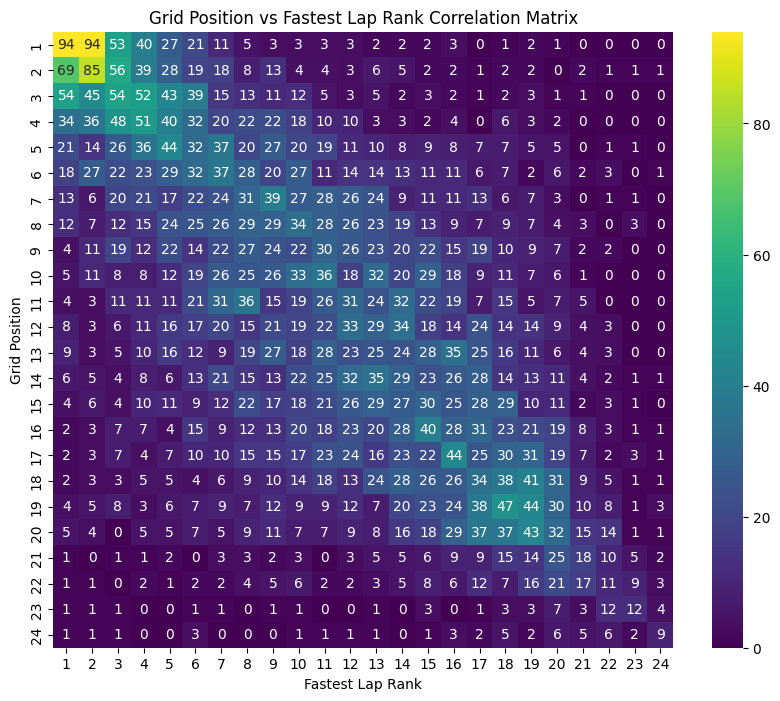

In [51]:
# Filter out rows where grid_position or fastestLapRank is 0
filtered_results_df = results_df[(results_df['grid_position'] != 0) & (results_df['fastestLapRank'] != 0)]

# Group by grid_position and fastestLapRank to get the frequency
frequency = filtered_results_df.groupby(['grid_position', 'fastestLapRank']).size().reset_index(name='count')

# Create a pivot table to form the correlation matrix
correlation_matrix = frequency.pivot_table(index='grid_position', columns='fastestLapRank', values='count', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='g', cmap='viridis')

plt.xlabel('Fastest Lap Rank')
plt.ylabel('Grid Position')
plt.title('Grid Position vs Fastest Lap Rank Correlation Matrix')

plt.show()


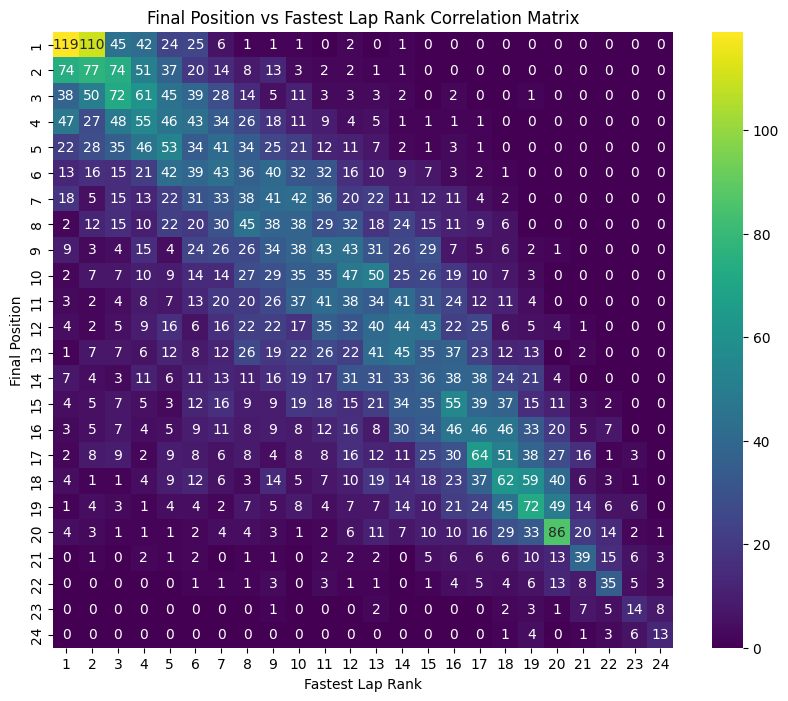

In [50]:
# Filter out rows where position or fastestLapRank is 0
filtered_results_df = results_df[(results_df['position'] != 0) & (results_df['fastestLapRank'] != 0)]

# Group by position and fastestLapRank to get the frequency
frequency = filtered_results_df.groupby(['position', 'fastestLapRank']).size().reset_index(name='count')

# Create a pivot table to form the correlation matrix
correlation_matrix = frequency.pivot_table(index='position', columns='fastestLapRank', values='count', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='g', cmap='viridis')

plt.xlabel('Fastest Lap Rank')
plt.ylabel('Final Position')
plt.title('Final Position vs Fastest Lap Rank Correlation Matrix')

plt.show()

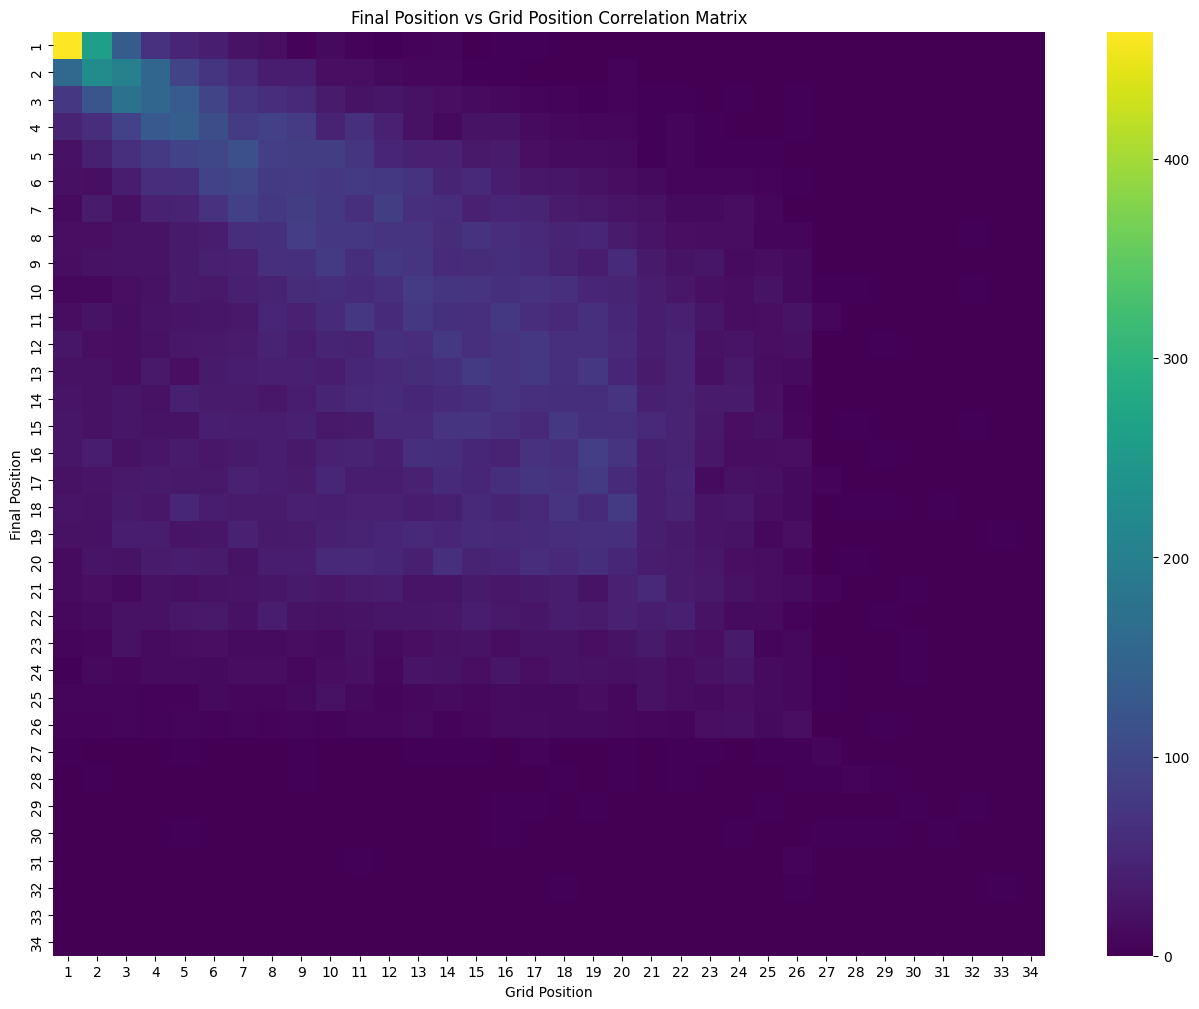

In [54]:
# Filter out rows where position or grid_position is 0
filtered_results_df = results_df[(results_df['position'] != 0) & (results_df['grid_position'] != 0)]

# Group by position and grid_position to get the frequency
frequency = filtered_results_df.groupby(['position', 'grid_position']).size().reset_index(name='count')

# Create a pivot table to form the correlation matrix
correlation_matrix = frequency.pivot_table(index='position', columns='grid_position', values='count', fill_value=0)

# Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, fmt='g', cmap='viridis')

plt.xlabel('Grid Position')
plt.ylabel('Final Position')
plt.title('Final Position vs Grid Position Correlation Matrix')

plt.show()